<a href="https://colab.research.google.com/github/chilakala-jahnavi/Customer_Segmentation_and_CLV_Analysis/blob/main/Customer_Segmentation_%26_CLV_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
df = pd.read_csv("/content/sample_data/digital_wallet_ltv_dataset.csv")

In [ ]:
df.head()

,Customer_ID,Age,Location,Income_Level,Total_Transactions,Avg_Transaction_Value,Max_Transaction_Value,Min_Transaction_Value,Total_Spent,Active_Days,Last_Transaction_Days_Ago,Loyalty_Points_Earned,Referral_Count,Cashback_Received,App_Usage_Frequency,Preferred_Payment_Method,Support_Tickets_Raised,Issue_Resolution_Time,Customer_Satisfaction_Score,LTV
0,cust_0000,54,Urban,Low,192,16736.384023,60216.834510,6525.814861,3.213386e+06,140,209,2114,25,2224.012140,Monthly,Debit Card,3,61.568590,1,3.279546e+05
1,cust_0001,67,Suburban,High,979,14536.734683,48350.100272,2186.742245,1.423146e+07,229,240,2960,20,4026.823518,Monthly,UPI,17,60.392889,8,1.437053e+06
2,cust_0002,44,Urban,High,329,7061.372800,32521.157187,2743.406808,2.323192e+06,73,21,3170,0,1441.011395,Monthly,Debit Card,11,45.305579,4,2.419387e+05
3,cust_0003,30,Rural,High,71,16426.876453,17827.896720,4360.784994,1.166308e+06,299,285,4756,35,4365.855580,Weekly,Wallet Balance,6,22.030191,1,1.284599e+05
4,cust_0004,58,Urban,Middle,878,10800.092660,17497.634534,4532.872520,9.482481e+06,236,329,1992,18,4161.523827,Daily,UPI,18,20.634723,5,9.569514e+05


In [ ]:
df.shape

(7000, 20)

In [ ]:
df.columns

Index(['Customer_ID', 'Age', 'Location', 'Income_Level', 'Total_Transactions',
       'Avg_Transaction_Value', 'Max_Transaction_Value',
       'Min_Transaction_Value', 'Total_Spent', 'Active_Days',
       'Last_Transaction_Days_Ago', 'Loyalty_Points_Earned', 'Referral_Count',
       'Cashback_Received', 'App_Usage_Frequency', 'Preferred_Payment_Method',
       'Support_Tickets_Raised', 'Issue_Resolution_Time',
       'Customer_Satisfaction_Score', 'LTV'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  7000 non-null   object 
 1   Age                          7000 non-null   int64  
 2   Location                     7000 non-null   object 
 3   Income_Level                 7000 non-null   object 
 4   Total_Transactions           7000 non-null   int64  
 5   Avg_Transaction_Value        7000 non-null   float64
 6   Max_Transaction_Value        7000 non-null   float64
 7   Min_Transaction_Value        7000 non-null   float64
 8   Total_Spent                  7000 non-null   float64
 9   Active_Days                  7000 non-null   int64  
 10  Last_Transaction_Days_Ago    7000 non-null   int64  
 11  Loyalty_Points_Earned        7000 non-null   int64  
 12  Referral_Count               7000 non-null   int64  
 13  Cashback_Received 

In [ ]:
df.describe()

,Age,Total_Transactions,Avg_Transaction_Value,Max_Transaction_Value,Min_Transaction_Value,Total_Spent,Active_Days,Last_Transaction_Days_Ago,Loyalty_Points_Earned,Referral_Count,Cashback_Received,Support_Tickets_Raised,Issue_Resolution_Time,Customer_Satisfaction_Score,LTV
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7.000000e+03,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7.000000e+03
mean,42.633714,501.221429,9946.831482,30159.596784,2981.549953,5.002022e+06,181.934857,183.847714,2501.545429,24.837000,2496.525032,10.017571,36.528007,5.479000,5.119197e+05
std,15.516036,286.277311,5780.880831,21996.108793,2197.342161,4.390495e+06,105.102598,105.063709,1446.680026,14.560352,1440.651412,6.037067,20.389399,2.860197,4.390551e+05
min,16.000000,1.000000,10.185827,31.857484,4.617966,1.498144e+03,1.000000,1.000000,0.000000,0.000000,0.234349,0.000000,1.019853,1.000000,3.770495e+03
25%,29.000000,252.000000,4907.466790,12224.329366,1233.066226,1.363991e+06,90.000000,93.000000,1254.750000,12.000000,1269.423703,5.000000,19.127302,3.000000,1.482058e+05
50%,43.000000,506.000000,9841.172643,25469.392130,2473.181073,3.756105e+06,182.000000,184.000000,2466.000000,25.000000,2478.943350,10.000000,36.257396,5.000000,3.878180e+05
75%,56.000000,744.000000,14955.048801,44515.414177,4378.759195,7.645508e+06,273.000000,275.000000,3792.250000,37.000000,3749.375251,15.000000,54.068594,8.000000,7.748578e+05
max,69.000000,1000.000000,19996.445086,98809.241533,9917.028823,1.946773e+07,365.000000,365.000000,5000.000000,50.000000,4999.698480,20.000000,71.978946,10.000000,1.956988e+06


In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Location,0
Income_Level,0
Total_Transactions,0
Avg_Transaction_Value,0
Max_Transaction_Value,0
Min_Transaction_Value,0
Total_Spent,0
Active_Days,0


In [ ]:
df = df.dropna()

In [ ]:
df

,Customer_ID,Age,Location,Income_Level,Total_Transactions,Avg_Transaction_Value,Max_Transaction_Value,Min_Transaction_Value,Total_Spent,Active_Days,Last_Transaction_Days_Ago,Loyalty_Points_Earned,Referral_Count,Cashback_Received,App_Usage_Frequency,Preferred_Payment_Method,Support_Tickets_Raised,Issue_Resolution_Time,Customer_Satisfaction_Score,LTV
0,cust_0000,54,Urban,Low,192,16736.384023,60216.834510,6525.814861,3.213386e+06,140,209,2114,25,2224.012140,Monthly,Debit Card,3,61.568590,1,3.279546e+05
1,cust_0001,67,Suburban,High,979,14536.734683,48350.100272,2186.742245,1.423146e+07,229,240,2960,20,4026.823518,Monthly,UPI,17,60.392889,8,1.437053e+06
2,cust_0002,44,Urban,High,329,7061.372800,32521.157187,2743.406808,2.323192e+06,73,21,3170,0,1441.011395,Monthly,Debit Card,11,45.305579,4,2.419387e+05
3,cust_0003,30,Rural,High,71,16426.876453,17827.896720,4360.784994,1.166308e+06,299,285,4756,35,4365.855580,Weekly,Wallet Balance,6,22.030191,1,1.284599e+05
4,cust_0004,58,Urban,Middle,878,10800.092660,17497.634534,4532.872520,9.482481e+06,236,329,1992,18,4161.523827,Daily,UPI,18,20.634723,5,9.569514e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,cust_6995,68,Suburban,High,340,162.703503,605.997495,80.352666,5.531919e+04,78,20,521,32,654.218655,Monthly,Credit Card,14,3.351374,3,1.244681e+04
6996,cust_6996,62,Suburban,High,647,1575.707877,4702.522747,359.511332,1.019483e+06,271,252,2972,40,3574.857418,Monthly,Wallet Balance,13,19.735330,3,1.131049e+05
6997,cust_6997,16,Urban,Middle,481,14429.355178,17207.737631,1510.598329,6.940520e+06,225,348,2423,8,2899.068571,Monthly,UPI,12,45.036932,2,7.002484e+05
6998,cust_6998,32,Urban,High,574,8005.027184,33203.795716,1976.326124,4.594886e+06,121,50,634,31,2432.363200,Monthly,Credit Card,11,44.145749,1,4.636404e+05


In [ ]:
df.describe(include='object')

,Customer_ID,Location,Income_Level,App_Usage_Frequency,Preferred_Payment_Method
count,7000,7000,7000,7000,7000
unique,7000,3,3,3,4
top,cust_6999,Urban,Middle,Daily,UPI
freq,1,2368,2391,2346,1791


In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].value_counts())


Customer_ID
Customer_ID
cust_6999    1
cust_0000    1
cust_0001    1
cust_0002    1
cust_0003    1
            ..
cust_0012    1
cust_0011    1
cust_0010    1
cust_0009    1
cust_0008    1
Name: count, Length: 7000, dtype: int64

Location
Location
Urban       2368
Suburban    2320
Rural       2312
Name: count, dtype: int64

Income_Level
Income_Level
Middle    2391
Low       2311
High      2298
Name: count, dtype: int64

App_Usage_Frequency
App_Usage_Frequency
Daily      2346
Monthly    2329
Weekly     2325
Name: count, dtype: int64

Preferred_Payment_Method
Preferred_Payment_Method
UPI               1791
Debit Card        1761
Wallet Balance    1736
Credit Card       1712
Name: count, dtype: int64


# **EDA (Exploratory Data Analysis):**

**Age Distribution**

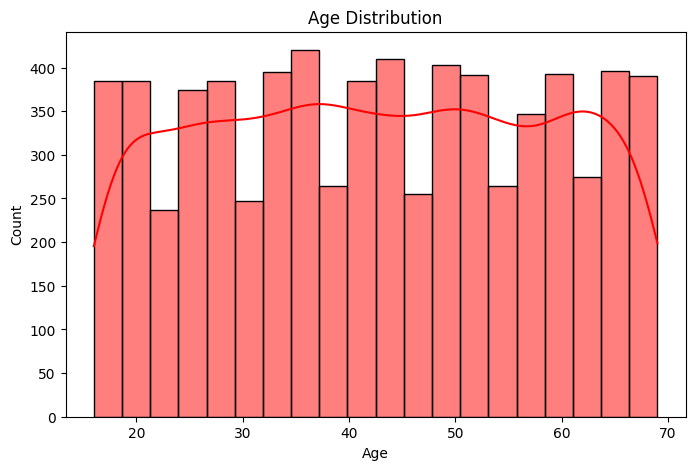

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True,color="red")
plt.title('Age Distribution')
plt.show()

**Income Level**

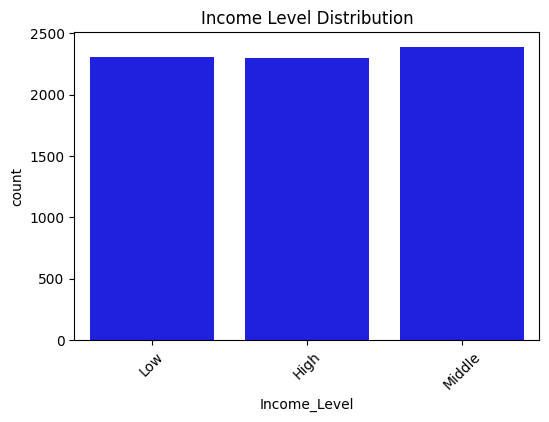

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Income_Level',color="blue")
plt.title('Income Level Distribution')
plt.xticks(rotation=45)
plt.show()

**Preferred Payment Method**

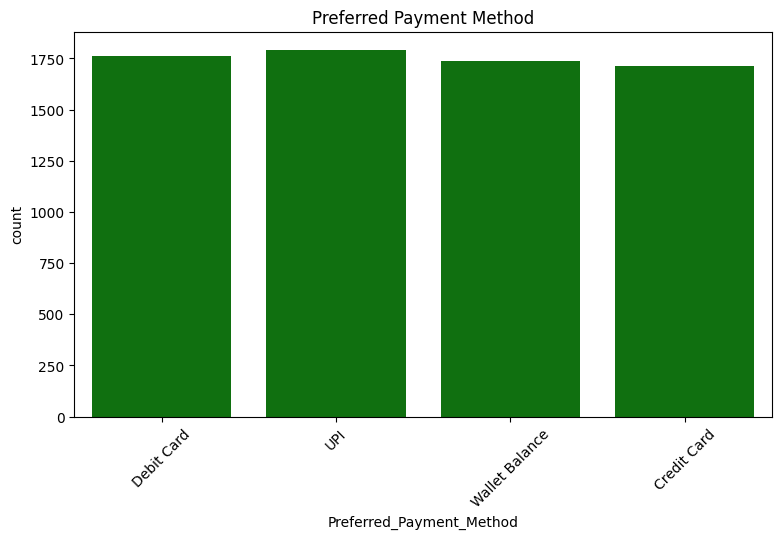

In [36]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x='Preferred_Payment_Method',color="green")
plt.title('Preferred Payment Method')
plt.xticks(rotation=45)
plt.show()

**Total Spent**

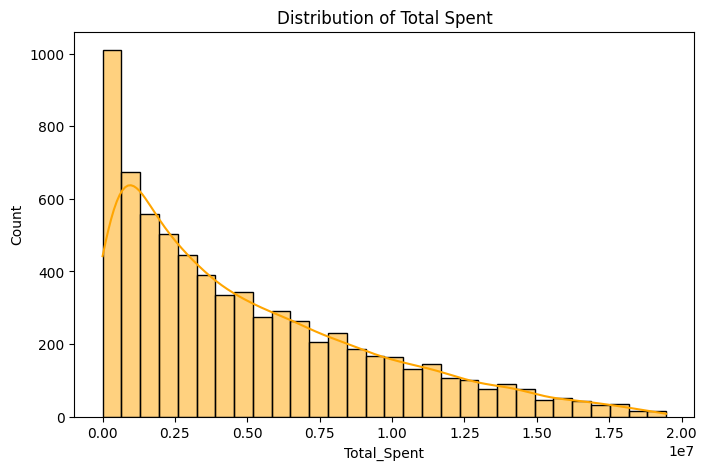

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total_Spent'], bins=30, kde=True,color="orange")
plt.title('Distribution of Total Spent')
plt.show()

**LTV Distribution**

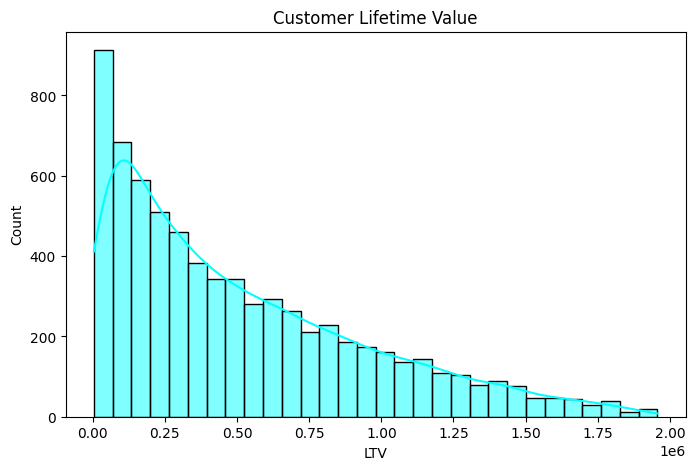

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(df['LTV'], bins=30, kde=True,color="aqua")
plt.title('Customer Lifetime Value')
plt.show()

**Correlation Heatmap**

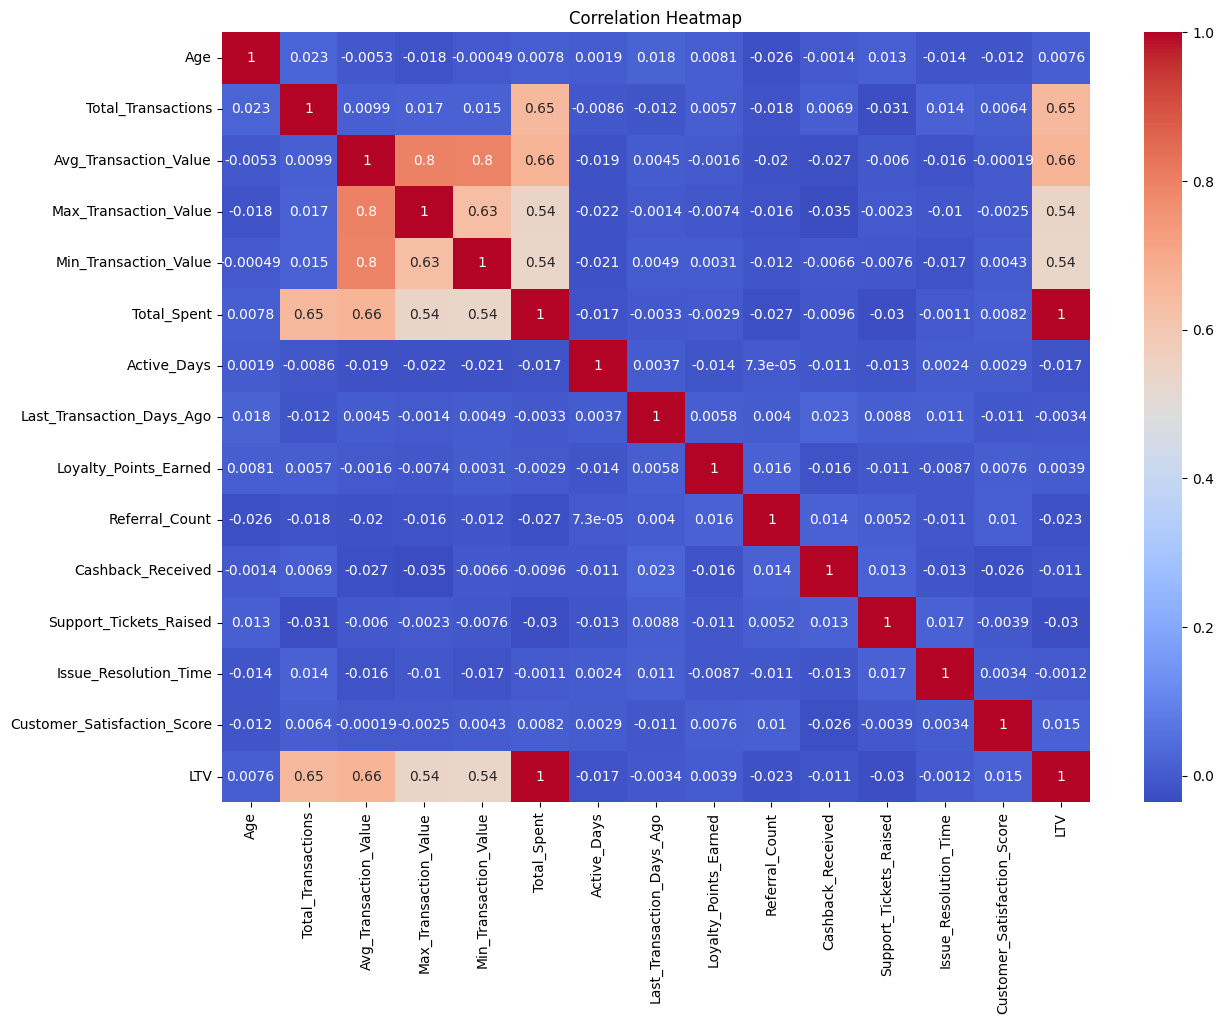

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()